<a href="https://colab.research.google.com/github/Lelytameyda29rpl/PCVK_Ganjil_2025/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **D. PRAKTIKUM FILTER**

**1. Buatlah fungsi konvolusi menggunakan algoritma yang telah dijelaskan pada Bagian C, tanpa menggunakan library atau metode konvolusi dari OpenCV.**

2. Berikut merupakan langkah-langkah yang dapat dilakukan:

**a. Buat notebook baru pada google colab, dan beri nama Week7.ipynb. Simpan Salinan pada akun github seperti pada modul sebelumnya.**

**b. Akses file yang terdapat pada drive dan import beberapa library yang dibutuhkan.**

In [1]:
# Import library yang diperlukan
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

**c. Buatlah fungsi konvolusi. Catatan: parameter yang digunakan boleh dimodifikasi. Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan padding.**


In [8]:
# Membuat fungsi konvolusi
def convolution2d(image, kernel, stride, padding):
    """
    Fungsi untuk melakukan konvolusi 2D pada citra
    Parameters:
    - image: citra input (grayscale)
    - kernel: matriks kernel untuk konvolusi
    - stride: besarnya pergeseran untuk setiap konvolusi
    - padding: jumlah padding yang akan ditambahkan
    """

    # Mendapatkan dimensi citra dan kernel
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Menghitung dimensi output
    output_height = (image_height + 2 * padding - kernel_height) // stride + 1
    output_width = (image_width + 2 * padding - kernel_width) // stride + 1

    # Membuat citra output
    output = np.zeros((output_height, output_width))

    # Menambahkan padding ke citra
    if padding > 0:
        image_padded = np.pad(image, padding, mode='constant', constant_values=0)
    else:
        image_padded = image

    # Proses konvolusi
    for y in range(0, output_height):
        for x in range(0, output_width):
            # Menghitung posisi window pada citra
            y_start = y * stride
            y_end = y_start + kernel_height
            x_start = x * stride
            x_end = x_start + kernel_width

            # Ekstrak region dari citra
            region = image_padded[y_start:y_end, x_start:x_end]

            # Melakukan operasi konvolusi
            output[y, x] = np.sum(region * kernel)

    return output

**d. Load citra yang akan diproses dan ubah menjadi citra keabuan**

Citra Asli (Grayscale):


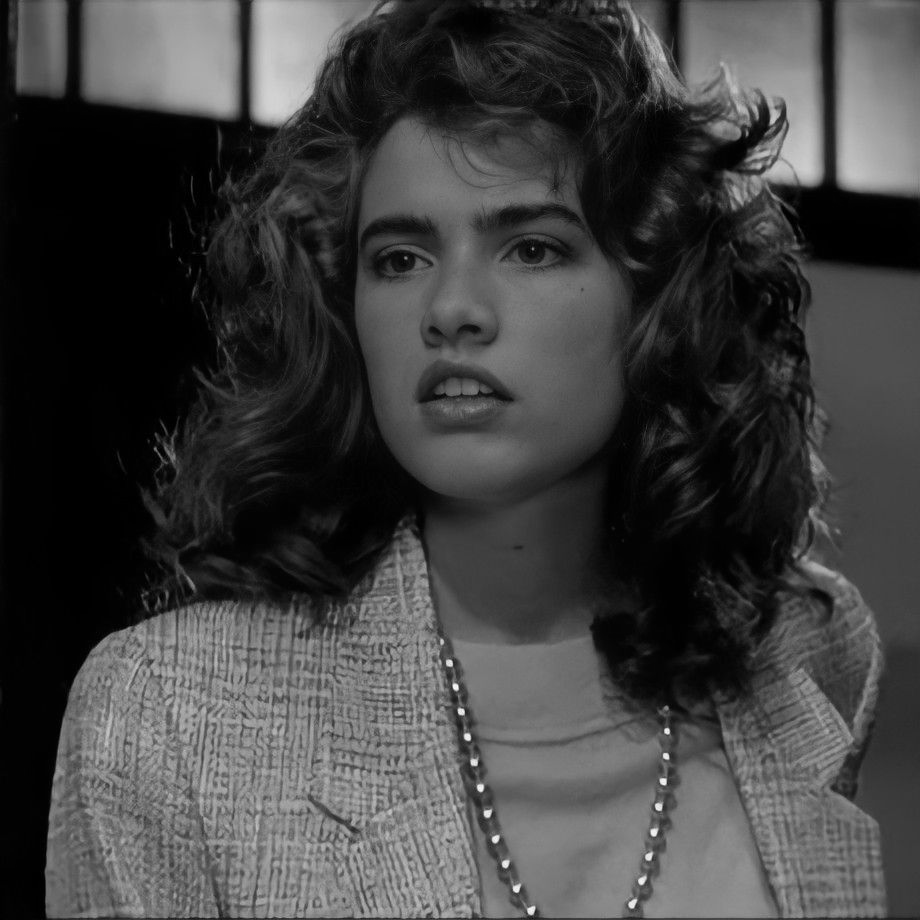

Dimensi citra: (920, 920)


In [9]:
# Load citra dan konversi ke grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/JS5/Images/female.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Menampilkan citra asli
print("Citra Asli (Grayscale):")
cv2_imshow(img_gray)
print(f"Dimensi citra: {img_gray.shape}")

**e. Tentukan kernel yang akan digunakan, contohnya kernel untuk filter sharpening sebagai berikut:**

In [10]:
# Mendefinisikan kernel sharpening
print("\n" + "="*50)
print("KERNEL SHARPENING")
print("="*50)

# Kernel Sharpening
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

print("Kernel Sharpening:")
print(kernel_sharpen)
print(f"Dimensi kernel: {kernel_sharpen.shape}")


KERNEL SHARPENING
Kernel Sharpening:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]
Dimensi kernel: (3, 3)


**f. Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil konvolusinya:**


Menerapkan Sharpening Filter...

Hasil Sharpening Filter:


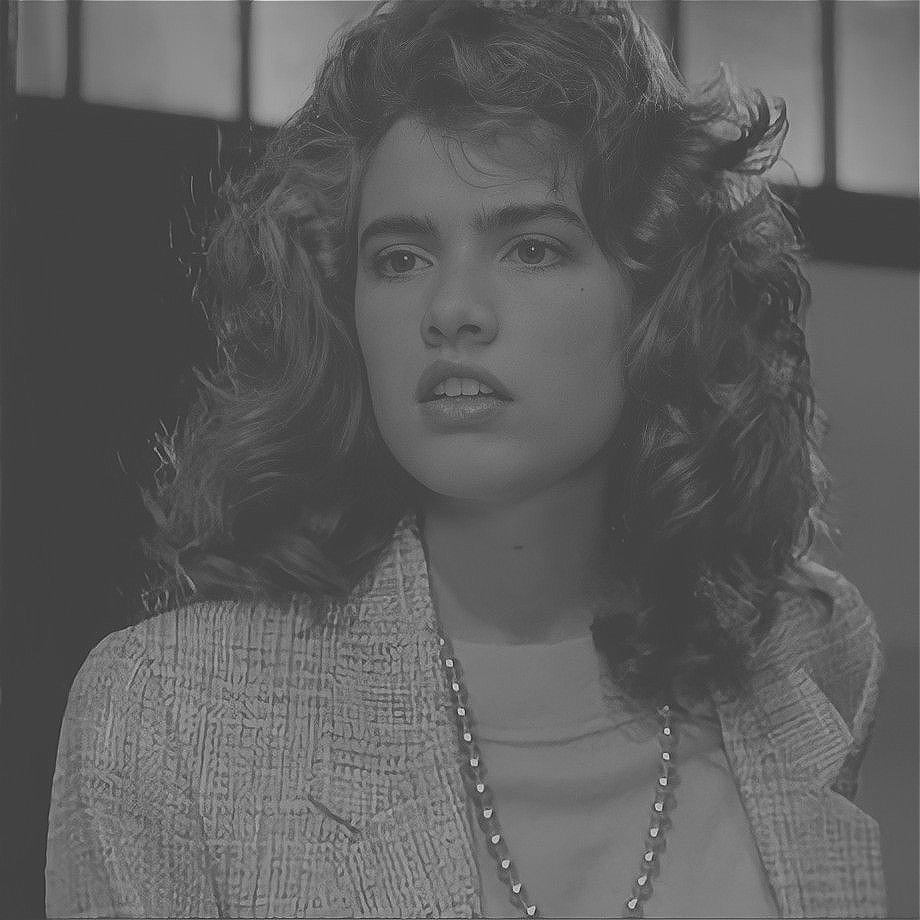


PERBANDINGAN: SEBELUM vs SESUDAH SHARPENING


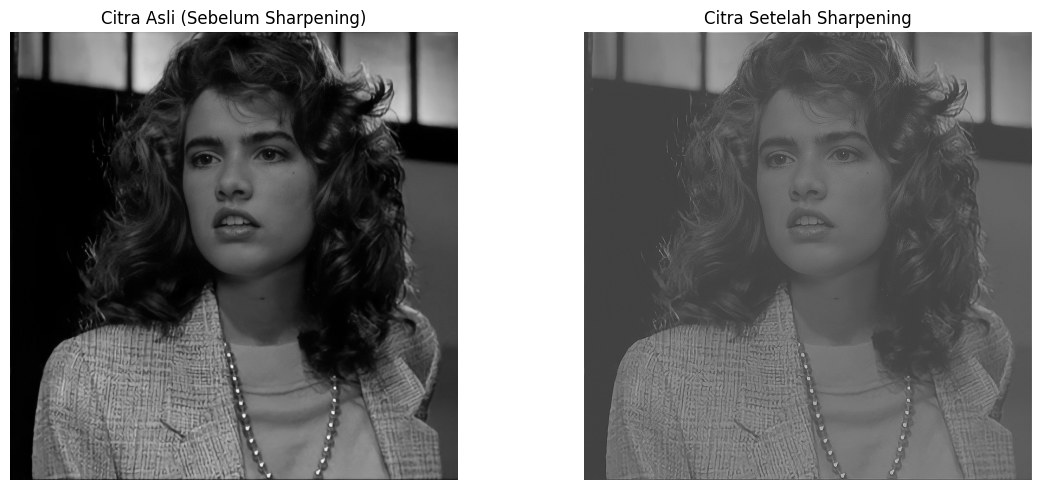


PENJELASAN KERNEL SHARPENING
Kernel Sharpening bekerja dengan prinsip:
1. Pusat kernel bernilai 5 (diperkuat)
2. Tetangga langsung (atas, bawah, kiri, kanan) bernilai -1
3. Diagonal bernilai 0 (tidak mempengaruhi)
4. Efek: Memperkuat perbedaan antara piksel pusat dan tetangganya
5. Hasil: Edges dan detail citra menjadi lebih tajam
6. Rumus: Output = 5*pusat - (atas + bawah + kiri + kanan)

Contoh perhitungan konvolusi:
Misal region citra 3x3:
[[100 100 100]
 [100 150 100]
 [100 100 100]]

Dikonvolusi dengan kernel sharpening:
Hasil: 350
Terlihat nilai pusat (150) diperkuat menjadi 550!


In [11]:
# Menerapkan kernel sharpening dan menampilkan hasil
print("\nMenerapkan Sharpening Filter...")

# Melakukan konvolusi
result_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)

# Normalisasi hasil untuk menampilkan gambar
result_sharpen_normalized = cv.normalize(result_sharpen, None, 0, 255, cv.NORM_MINMAX)
result_sharpen_uint8 = np.uint8(result_sharpen_normalized)

print("\nHasil Sharpening Filter:")
cv2_imshow(result_sharpen_uint8)

# Menampilkan perbandingan side-by-side
print("\n" + "="*50)
print("PERBANDINGAN: SEBELUM vs SESUDAH SHARPENING")
print("="*50)

plt.figure(figsize=(12, 5))

# Citra asli
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli (Sebelum Sharpening)')
plt.axis('off')

# Citra setelah sharpening
plt.subplot(1, 2, 2)
plt.imshow(result_sharpen_uint8, cmap='gray')
plt.title('Citra Setelah Sharpening')
plt.axis('off')

plt.tight_layout()
plt.show()

# Penjelasan tentang kernel sharpening
print("\n" + "="*50)
print("PENJELASAN KERNEL SHARPENING")
print("="*50)
print("Kernel Sharpening bekerja dengan prinsip:")
print("1. Pusat kernel bernilai 5 (diperkuat)")
print("2. Tetangga langsung (atas, bawah, kiri, kanan) bernilai -1")
print("3. Diagonal bernilai 0 (tidak mempengaruhi)")
print("4. Efek: Memperkuat perbedaan antara piksel pusat dan tetangganya")
print("5. Hasil: Edges dan detail citra menjadi lebih tajam")
print("6. Rumus: Output = 5*pusat - (atas + bawah + kiri + kanan)")

# Menghitung contoh konvolusi sederhana
print("\nContoh perhitungan konvolusi:")
print("Misal region citra 3x3:")
sample_region = np.array([[100, 100, 100],
                         [100, 150, 100],
                         [100, 100, 100]])
print(sample_region)

print("\nDikonvolusi dengan kernel sharpening:")
result_sample = np.sum(sample_region * kernel_sharpen)
print(f"Hasil: {result_sample}")
print("Terlihat nilai pusat (150) diperkuat menjadi 550!")